Assignment-11
Decision Tree

In [153]:
import numpy as np
import pandas as pd

In [154]:
excel_file = pd.ExcelFile('/content/heart_disease.xlsx')
excel_file.sheet_names

['Description', 'Heart_disease']

In [155]:
df = pd.read_excel('/content/heart_disease.xlsx', sheet_name='Heart_disease')

In [156]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,num
0,63,Male,typical angina,145,233,True,lv hypertrophy,150,False,2.3,downsloping,fixed defect,0
1,41,Male,atypical angina,135,203,False,normal,132,False,0.0,flat,fixed defect,0
2,57,Male,asymptomatic,140,192,False,normal,148,False,0.4,flat,fixed defect,0
3,52,Male,typical angina,118,186,False,lv hypertrophy,190,False,0.0,flat,fixed defect,0
4,57,Male,asymptomatic,110,201,False,normal,126,True,1.5,flat,fixed defect,0


In [157]:
df.shape

(908, 13)

In [158]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 908 entries, 0 to 907
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       908 non-null    int64  
 1   sex       908 non-null    object 
 2   cp        908 non-null    object 
 3   trestbps  908 non-null    int64  
 4   chol      908 non-null    int64  
 5   fbs       908 non-null    bool   
 6   restecg   908 non-null    object 
 7   thalch    908 non-null    int64  
 8   exang     908 non-null    object 
 9   oldpeak   846 non-null    float64
 10  slope     908 non-null    object 
 11  thal      908 non-null    object 
 12  num       908 non-null    int64  
dtypes: bool(1), float64(1), int64(5), object(6)
memory usage: 86.1+ KB


In [159]:
df.describe()

,age,trestbps,chol,thalch,oldpeak,num
count,908.000000,908.000000,908.000000,908.000000,846.000000,908.000000
mean,53.791850,133.430617,201.484581,135.957048,0.891253,1.008811
std,9.158031,20.401608,112.097949,26.804929,1.093875,1.144436
min,29.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.750000,120.000000,176.750000,118.000000,0.000000,0.000000
50%,54.000000,130.000000,224.000000,138.000000,0.500000,1.000000
75%,60.000000,144.000000,270.000000,156.000000,1.500000,2.000000
max,77.000000,200.000000,603.000000,202.000000,6.200000,4.000000


In [160]:
df.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalch,0
exang,0
oldpeak,62


In [161]:
df.dtypes

,0
age,int64
sex,object
cp,object
trestbps,int64
chol,int64
fbs,bool
restecg,object
thalch,int64
exang,object
oldpeak,float64


In [162]:
df.duplicated().sum()

np.int64(1)

In [163]:
df.dtypes

,0
age,int64
sex,object
cp,object
trestbps,int64
chol,int64
fbs,bool
restecg,object
thalch,int64
exang,object
oldpeak,float64


In [164]:
df.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalch',
       'exang', 'oldpeak', 'slope', 'thal', 'num'],
      dtype='object')

In [165]:
import matplotlib.pyplot as plt
import seaborn as sns

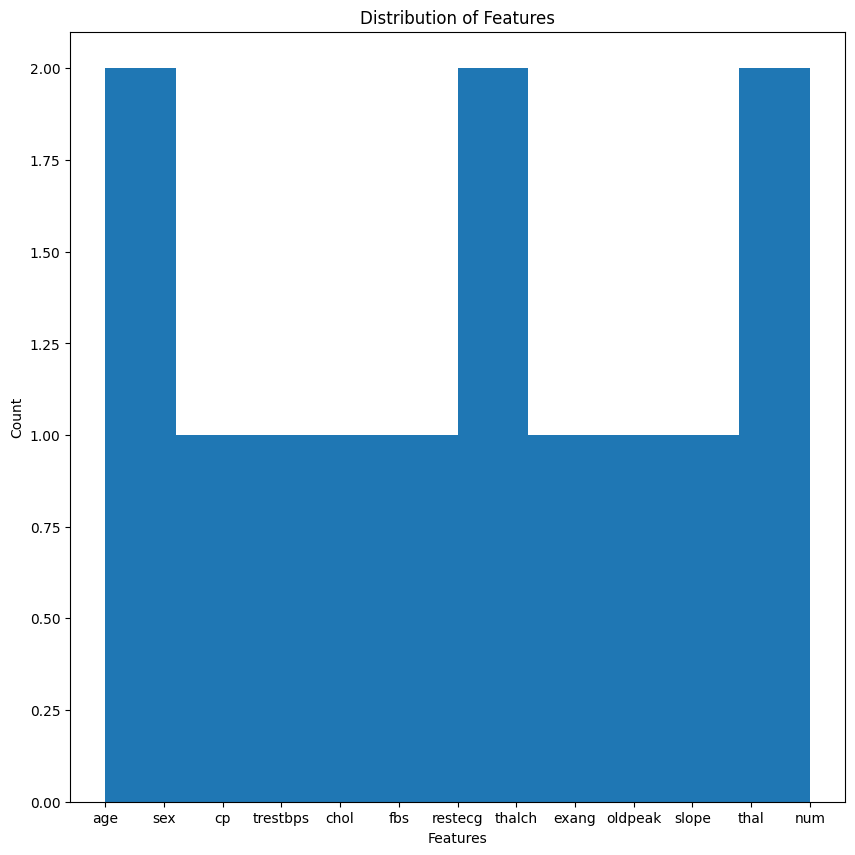

In [166]:
plt.figure(figsize=(10,10))
plt.hist(df.columns)
plt.xlabel('Features')
plt.ylabel('Count')
plt.title('Distribution of Features')
plt.show()

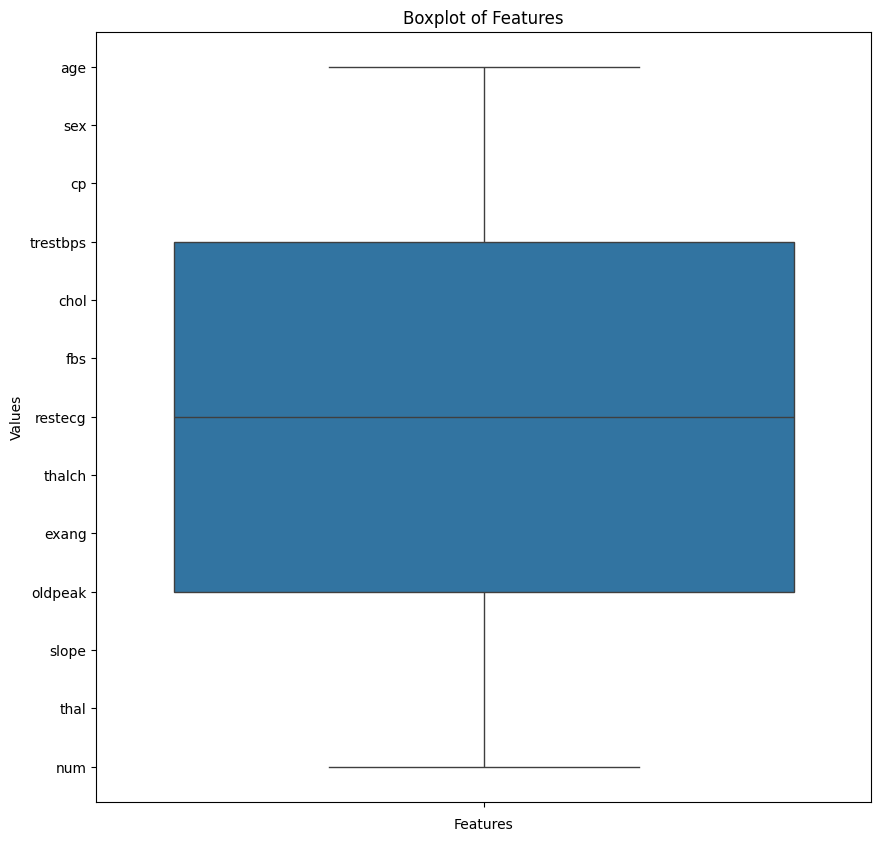

In [167]:
plt.figure(figsize=(10,10))
sns.boxplot(df.columns)
plt.xlabel('Features')
plt.ylabel('Values')
plt.title('Boxplot of Features')
plt.show()

In [168]:
df.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalch,0
exang,0
oldpeak,62


In [169]:
df.dtypes

,0
age,int64
sex,object
cp,object
trestbps,int64
chol,int64
fbs,bool
restecg,object
thalch,int64
exang,object
oldpeak,float64


In [170]:
df.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalch',
       'exang', 'oldpeak', 'slope', 'thal', 'num'],
      dtype='object')

In [171]:
df.duplicated().sum()

np.int64(1)

In [172]:
df.drop_duplicates(inplace=True)

In [173]:
df.duplicated().sum()

np.int64(0)

In [174]:
for col in ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']:
    print(col, df[col].unique())

sex ['Male' 'Female']
cp ['typical angina' 'atypical angina' 'asymptomatic' 'non-anginal']
fbs [ True False]
restecg ['lv hypertrophy' 'normal' 'st-t abnormality']
exang [False True 'FALSE' 'TURE']
slope ['downsloping' 'flat' 'upsloping']
thal ['fixed defect' 'normal' 'reversable defect']


In [175]:
from sklearn.preprocessing import LabelEncoder

label = LabelEncoder()

categorical_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']

for col in categorical_cols:
    df[col] = df[col].astype(str)
    df[col] = label.fit_transform(df[col])

df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,num
0,63,1,3,145,233,1,0,150,1,2.3,0,0,0
1,41,1,1,135,203,0,1,132,1,0.0,1,0,0
2,57,1,0,140,192,0,1,148,1,0.4,1,0,0
3,52,1,3,118,186,0,0,190,1,0.0,1,0,0
4,57,1,0,110,201,0,1,126,3,1.5,1,0,0


In [176]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,num
0,63,1,3,145,233,1,0,150,1,2.3,0,0,0
1,41,1,1,135,203,0,1,132,1,0.0,1,0,0
2,57,1,0,140,192,0,1,148,1,0.4,1,0,0
3,52,1,3,118,186,0,0,190,1,0.0,1,0,0
4,57,1,0,110,201,0,1,126,3,1.5,1,0,0


In [177]:
from sklearn.preprocessing import StandardScaler
scaler =StandardScaler()

In [178]:
numerical_cols = ['age', 'trestbps', 'chol', 'thalch', 'oldpeak']

In [179]:
df[numerical_cols] = scaler.fit_transform(df[numerical_cols])

In [180]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,num
0,1.006097,1,3,0.568184,0.281318,1,0,0.523285,1,1.287392,0,0,0
1,-1.396447,1,1,0.077848,0.013691,0,1,-0.148399,1,-0.816052,1,0,0
2,0.350858,1,0,0.323016,-0.084439,0,1,0.448654,1,-0.450236,1,0,0
3,-0.195175,1,3,-0.755723,-0.137964,0,0,2.015918,1,-0.816052,1,0,0
4,0.350858,1,0,-1.147992,-0.004151,0,1,-0.372294,3,0.555760,1,0,0


In [181]:
df[numerical_cols].mean()

,0
age,3.133595e-16
trestbps,-3.133595e-17
chol,7.833988e-17
thalch,1.566798e-16
oldpeak,-3.363516e-17


In [182]:
df[numerical_cols].std()

,0
age,1.000552
trestbps,1.000552
chol,1.000552
thalch,1.000552
oldpeak,1.000592


In [183]:
X = df.drop('num', axis=1)
y = df['num']

In [184]:

X.shape

(907, 12)

In [185]:
y.shape

(907,)

In [186]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [187]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((725, 12), (182, 12), (725,), (182,))

In [188]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [189]:
model= DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [190]:
y_pred = model.predict(X_test)


In [191]:
y_pred

array([0, 1, 0, 2, 2, 2, 1, 0, 1, 1, 2, 0, 0, 0, 1, 1, 0, 0, 2, 1, 0, 0,
       1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 3, 0, 0, 3, 0,
       2, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 4, 0, 3, 2, 1, 0, 3, 1, 0, 1,
       3, 1, 0, 0, 0, 3, 3, 1, 0, 0, 1, 0, 1, 0, 2, 1, 0, 0, 0, 0, 0, 2,
       3, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 2, 0, 0, 1, 1, 1, 1,
       0, 0, 3, 2, 0, 1, 1, 1, 2, 0, 1, 0, 0, 3, 1, 0, 0, 1, 2, 1, 1, 0,
       0, 1, 3, 0, 2, 1, 3, 0, 1, 0, 0, 0, 0, 1, 0, 0, 2, 1, 4, 0, 0, 0,
       0, 1, 0, 0, 2, 0, 1, 0, 0, 1, 0, 2, 3, 2, 2, 0, 1, 1, 0, 0, 0, 0,
       2, 1, 1, 4, 3, 0])

In [192]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.5604395604395604


In [193]:
from sklearn.metrics import confusion_matrix
confusion = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(confusion)

Confusion Matrix:
[[67 14  4  3  1]
 [11 26  3  5  2]
 [ 4  8  6  2  0]
 [ 4  7  3  3  0]
 [ 3  1  4  1  0]]


In [194]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.75      0.75      0.75        89
           1       0.46      0.55      0.50        47
           2       0.30      0.30      0.30        20
           3       0.21      0.18      0.19        17
           4       0.00      0.00      0.00         9

    accuracy                           0.56       182
   macro avg       0.35      0.36      0.35       182
weighted avg       0.54      0.56      0.55       182



In [195]:
from sklearn.metrics import precision_score, recall_score, f1_score

In [196]:
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Precision: 0.5410125588697017
Recall: 0.5604395604395604
F1 Score: 0.5495520764859945


In [200]:
from sklearn.metrics import roc_auc_score

In [202]:
y_prob = model.predict_proba(X_test)

roc_auc = roc_auc_score(
    y_test,
    y_prob,
    multi_class='ovr',
    average='weighted'
)

print("ROC-AUC Score:", roc_auc)

ROC-AUC Score: 0.6853955888886586


In [203]:
from sklearn.model_selection import GridSearchCV

In [204]:
param_grid = {
    'max_depth': [3, 5, 7, 10],
    'min_samples_split': [2, 5, 10],
    'criterion': ['gini', 'entropy']
}

In [207]:
from sklearn.model_selection import GridSearchCV

grid = GridSearchCV(
    model,
    param_grid,
    cv=5,
    scoring='accuracy'
)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best CV Accuracy:", grid.best_score_)

Best Parameters: {'criterion': 'gini', 'max_depth': 3, 'min_samples_split': 2}
Best CV Accuracy: 0.5448275862068965


In [208]:
best_model = grid.best_estimator_
y_pred = best_model.predict(X_test)
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred)
print("Test Accuracy:", accuracy)

Test Accuracy: 0.5769230769230769


In [212]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred_tuned = best_model.predict(X_test)

accuracy_tuned = accuracy_score(y_test, y_pred_tuned)
print("Tuned Model Accuracy:", accuracy_tuned)

print("Tuned Model Classification Report:")
print(classification_report(y_test, y_pred_tuned))


Tuned Model Accuracy: 0.5769230769230769
Tuned Model Classification Report:
              precision    recall  f1-score   support

           0       0.72      0.87      0.79        89
           1       0.42      0.57      0.49        47
           2       0.00      0.00      0.00        20
           3       0.09      0.06      0.07        17
           4       0.00      0.00      0.00         9

    accuracy                           0.58       182
   macro avg       0.25      0.30      0.27       182
weighted avg       0.47      0.58      0.52       182



/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


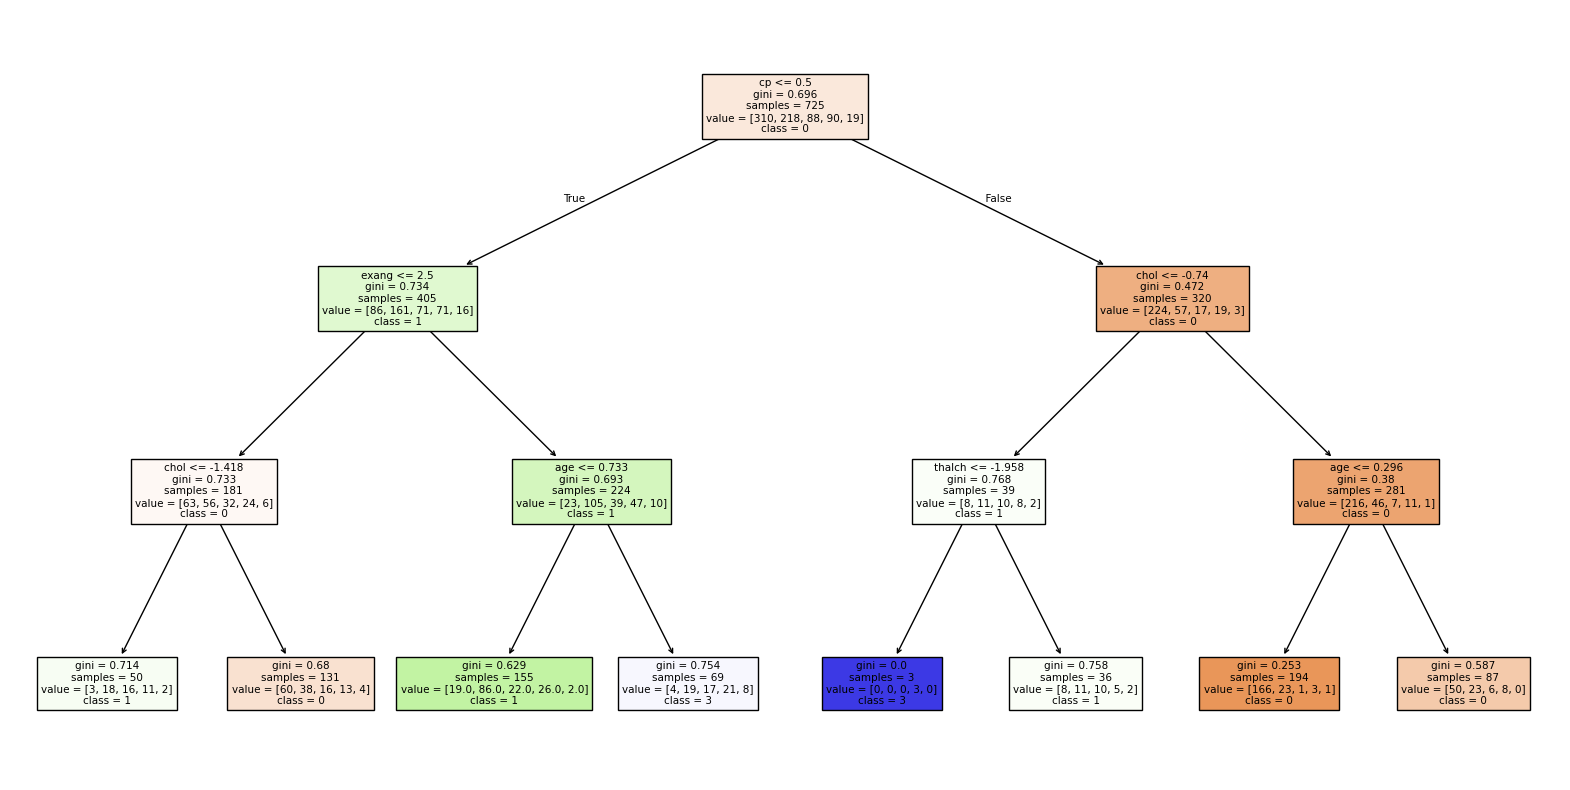

In [216]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 10))

plot_tree(
    best_model,
    feature_names=X.columns,
    class_names=[str(x) for x in best_model.classes_],
    filled=True
)

plt.show()

In [217]:
import pandas as pd

feature_importance = pd.Series(
    best_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print(feature_importance)

cp          0.548488
chol        0.214831
age         0.121314
exang       0.089369
thalch      0.025998
sex         0.000000
trestbps    0.000000
fbs         0.000000
restecg     0.000000
oldpeak     0.000000
slope       0.000000
thal        0.000000
dtype: float64


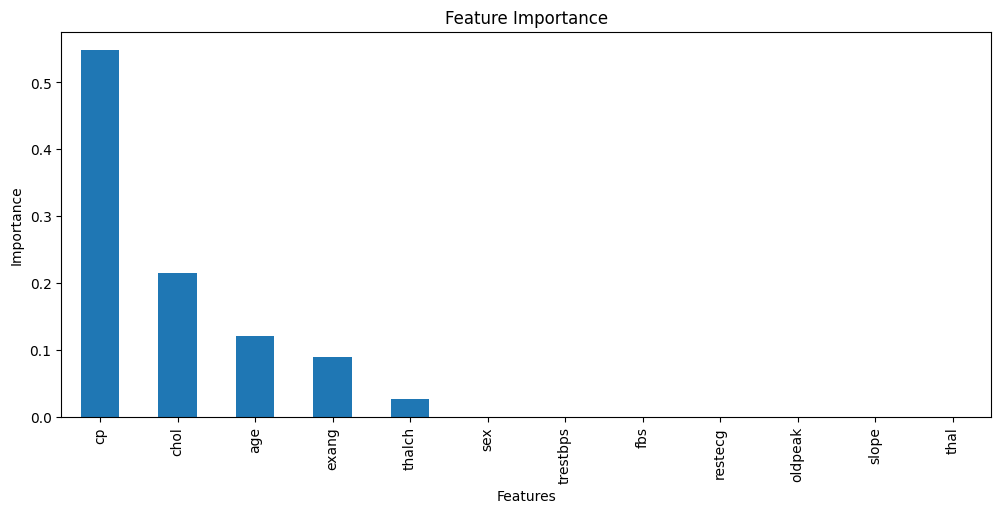

In [218]:
feature_importance.plot(kind='bar', figsize=(12, 5))

plt.title("Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.show()

1. Common Decision Tree Hyperparameters

- max_depth -Controls the maximum depth of the tree.
- min_samples_split - Minimum samples required to split a node.
- min_samples_leaf - Minimum samples required in a leaf.
- criterion - Measures the quality of a split (gini, entropy).
- These hyperparameters help control overfitting and underfitting.


2. Label Encoding vs One-Hot Encoding

- Label Encoding -Converts categories into numbers.
  Example: Male -1, Female - 0

- One-Hot Encoding - Converts categories into separate 0/1 columns.

- Label Encoding - One column.
- One-Hot Encoding - Multiple columns.